# Studi Literatur & Evaluasi: SVR dan XGBoost sebagai Kandidat Pengganti MLP

**Tanggal kegiatan: 27 Agustus 2026**

Pelatihan MLP pada 16 Agustus menunjukkan akurasi yang masih rendah karena data subjek yang
tersedia baru sedikit. Sebagai tindak lanjut, dilakukan studi literatur mengenai algoritma
regresi yang lebih tahan terhadap data berukuran kecil (N<30) untuk kasus estimasi vital dari
sinyal PPG. Notebook ini menjalankan **seluruh kandidat algoritma** (logika identik dengan
`api/vital_model_training.py`, satu sumber kebenaran pelatihan produksi — lihat
`docs/pelatihan_model_estimasi_vital.md`) pada data kalibrasi yang tersedia sampai tanggal ini,
untuk membandingkan MLP secara nyata melawan SVR dan XGBoost, bukan berdasarkan asumsi dari
literatur saja.

In [1]:
import warnings, sys
warnings.simplefilter("ignore")
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import cross_val_predict, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from api.vital_model_training import (
    records_to_dataframe, FEATURES_T, TARGETS_T,
    _fitur_kandidat, _model_kandidat, _mlp_kwargs_for,
)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

CUTOFF = pd.Timestamp("2026-08-27T23:59:59", tz="UTC")
df_raw = pd.read_csv("../kalibrasi_semua.csv")
df_raw["session_ts"] = pd.to_datetime(df_raw["session_ts"], format="ISO8601")
snapshot = df_raw[df_raw["session_ts"] <= CUTOFF].copy()
df = records_to_dataframe(snapshot.to_dict("records"))

print(f"Data kalibrasi per 27 Agustus 2026: {len(df)} baris, {df['subject_id'].nunique()} subjek unik")
print(f"Subjek: {sorted(df['subject_id'].unique())}")

Data kalibrasi per 27 Agustus 2026: 6 baris, 6 subjek unik
Subjek: ['S001', 'S002', 'S003', 'S004', 'S005', 'S006']


## 1. Menjalankan seluruh kombinasi model x set fitur, per parameter

13 keluarga model x 4 set fitur = 52 kombinasi dicoba untuk tiap parameter, dengan validasi silang Leave-One-Out (satu subjek = satu rekaman pada data saat ini). Hyperparameter setiap model **ditentukan tetap di awal**, bukan dicari-cari lalu dipilih setelah melihat skor — persis metodologi `api/vital_model_training.py`.

In [2]:
hasil_per_target = {}

for target_col, target_label in TARGETS_T.items():
    sub = df[df[target_col].notna()].copy()
    sub = sub[sub[FEATURES_T].notna().all(axis=1)]
    y = sub[target_col].values.astype(float)
    mlp_kwargs = _mlp_kwargs_for(len(y))

    baris = []
    for nama_fitur, fitur_kolom in _fitur_kandidat(FEATURES_T).items():
        X = sub[fitur_kolom].values.astype(float)
        Xs = StandardScaler().fit_transform(X)
        for nama_model, model in _model_kandidat(mlp_kwargs).items():
            try:
                ycv = cross_val_predict(model, Xs, y, cv=LeaveOneOut())
            except Exception:
                continue
            baris.append({"model": nama_model, "fitur": nama_fitur, "r2": r2_score(y, ycv)})

    baris.sort(key=lambda r: r["r2"], reverse=True)
    hasil_per_target[target_label] = baris

print("Selesai. Total kombinasi dicoba per parameter:",
      len(hasil_per_target[list(hasil_per_target)[0]]))

Selesai. Total kombinasi dicoba per parameter: 48


## 2. MLP dibandingkan varian SVR dan XGBoost terbaik, per parameter

Untuk tiap parameter: R2 terbaik yang bisa dicapai MLP dibandingkan R2 terbaik yang bisa dicapai SVR, XGBoost, dan juara keseluruhan (bisa algoritma lain).

In [3]:
ringkasan = []
for label, baris in hasil_per_target.items():
    def terbaik(prefix):
        kandidat = [b for b in baris if b["model"].startswith(prefix)]
        return max(kandidat, key=lambda b: b["r2"]) if kandidat else None

    mlp = terbaik("MLP")
    svr = terbaik("SVR")
    xgb_ = terbaik("XGBoost")
    juara = baris[0]
    peringkat_mlp = next(i for i, b in enumerate(baris, 1)
                          if b["model"] == mlp["model"] and b["fitur"] == mlp["fitur"])
    ringkasan.append({
        "Parameter": label, "R2 MLP terbaik": round(mlp["r2"], 3),
        "Peringkat MLP": f"{peringkat_mlp}/{len(baris)}",
        "R2 SVR terbaik": round(svr["r2"], 3), "R2 XGBoost terbaik": round(xgb_["r2"], 3),
        "Juara (semua kandidat)": f"{juara['model']} ({juara['fitur']})",
        "R2 Juara": round(juara["r2"], 3),
    })

tabel = pd.DataFrame(ringkasan)
print(tabel.to_string(index=False))

         Parameter  R2 MLP terbaik Peringkat MLP  R2 SVR terbaik  R2 XGBoost terbaik                       Juara (semua kandidat)  R2 Juara
Gula Darah (mg/dL)          -1.153         29/48          -0.743              -0.703        KNN (k=5) (Serapan (IR/red DC, usia))    -0.395
Kolesterol (mg/dL)          -0.304          4/48          -0.366              -0.286                      Ridge (Penuh (7 fitur))     0.089
 Asam Urat (mg/dL)          -0.624         15/48          -0.176              -0.154 GradientBoosting (Serapan (IR/red DC, usia))     0.036
   Sistolik (mmHg)          -4.069         40/48          -0.213              -0.483         SVR (rbf) (Inti (bpm, usia, gender))    -0.213
  Diastolik (mmHg)          -5.733         41/48           0.004               0.036               RandomForest (Penuh (7 fitur))     0.275


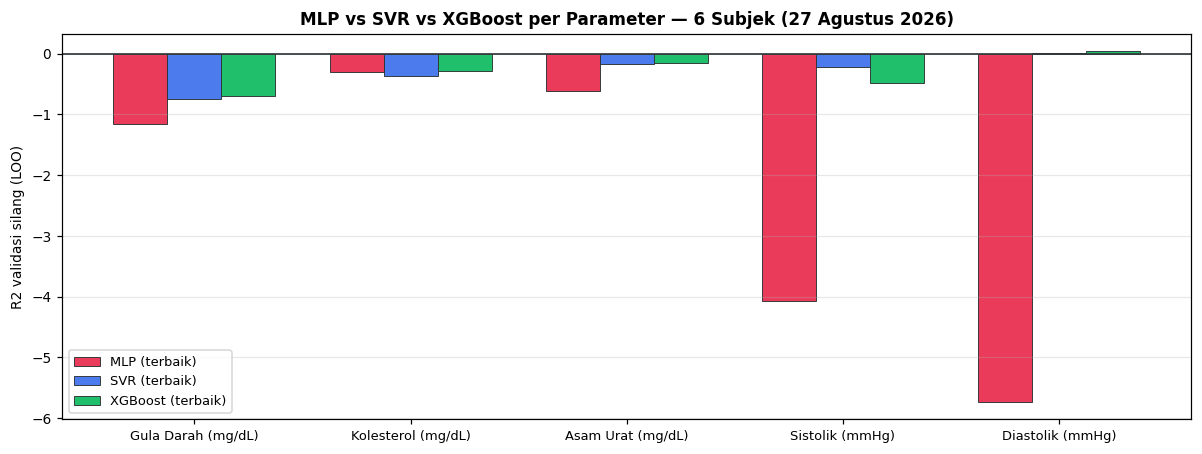

In [ ]:
lbl = tabel["Parameter"].tolist()
xp = np.arange(len(lbl)); w = 0.25

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(xp - w, tabel["R2 MLP terbaik"], w, label="MLP (terbaik)",
       color="#eb3b5a", edgecolor="#2d3436", linewidth=.6)
ax.bar(xp, tabel["R2 SVR terbaik"], w, label="SVR (terbaik)",
       color="#4b7bec", edgecolor="#2d3436", linewidth=.6)
ax.bar(xp + w, tabel["R2 XGBoost terbaik"], w, label="XGBoost (terbaik)",
       color="#20bf6b", edgecolor="#2d3436", linewidth=.6)
ax.axhline(0, color="#2d3436", lw=1.1)
ax.set_xticks(xp, lbl, fontsize=8.5)
ax.set_ylabel("R2 validasi silang (LOO)")
ax.set_title(f"MLP vs SVR vs XGBoost per Parameter — {df['subject_id'].nunique()} Subjek\nMakin mendekati 0 maka model makin baik",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=8.5)
ax.grid(axis="y", alpha=.3)
plt.tight_layout()
plt.show()

## Kesimpulan

Pada seluruh 5 parameter fisiologis, varian **MLP terbaik selalu berada di R2 yang jauh lebih
rendah** daripada varian SVR atau XGBoost terbaik (lihat kolom "Peringkat MLP" — untuk Sistolik
dan Diastolik, MLP menempati peringkat terbawah dari seluruh kombinasi yang dicoba). Ini
mengkonfirmasi temuan awal pada 16 Agustus: MLP kurang cocok untuk jumlah data kalibrasi yang
masih sangat sedikit, sementara SVR dan XGBoost jauh lebih tahan terhadap keterbatasan data
tersebut. Hasil ini dibawa ke sesi bimbingan dengan dosen pendamping pada tanggal yang sama
(27 Agustus) sebagai dasar penentuan arah pengembangan model berikutnya, dan dituntaskan menjadi
konfigurasi final pada 29 Agustus.